# Lab 7.2 — RAG over Government Documents

*Chapter 7 — Building with LLMs: APIs, RAG, and Agents · 40 minutes · JupyterLab + OpenAI API (local embedding fallback offline)*

Four agency policy documents and a question whose answer is buried in one of
them. This is the pattern behind every "chat with our documents" pilot:
retrieve the right chunks, ground the answer in them, force citations — and
verify those citations instead of trusting them.

Cells marked `# YOUR TURN` ask you to edit ordinary text (a question, an
instruction) or a number, and re-run the cell. Every cell runs as shipped:
labelled canned answers keep the lab moving, and embeddings fall back to a
deterministic local hasher when there is no key — so retrieval still works
end to end, with no network.

## Objectives

By the end of this lab, you will:

- Build a working retrieval pipeline over real policy documents.
- Force citations and verify them.
- Diagnose retrieval failure rather than blaming the model.

## Setup

- **Corpus (synthetic training documents, modelled on public federal practice):**
  - `data/corpus/ai_acceptable_use_policy.md`
  - `data/corpus/data_governance_standard.md`
  - `data/corpus/foia_processing_guidance.md`
  - `data/corpus/records_retention_policy.md`
- **Key:** `OPENAI_API_KEY` from the environment / course `.env` (never printed).
  Without it, chunk embeddings use a deterministic local fallback and
  generation returns labelled canned answers — retrieval still works end to
  end.
- **How this notebook works:** every step is one provided cell — run it with
  Shift+Enter and read what it prints. Cells marked `# YOUR TURN` ask you to
  edit the text (ordinary quoted text — no code) or a number, and re-run the
  cell. Everything runs as shipped, so you can never get stuck.

In [1]:
# ▶ Setup — run this cell first (click it, then Shift+Enter).
# It loads the course helper functions used by every step below.
from lab_helpers import *
lab_status()

.env loaded from: /home/student/1258-new/.env
chat model alias  : gpt-5-mini
embedding model   : text-embedding-3-small
API key configured: no — OFFLINE mode, canned replies below
data directory    : /home/student/1258-new/labs/data


The pipeline you are about to build — keep this picture in mind; every step
below is one box of it. Run the cell to draw it.

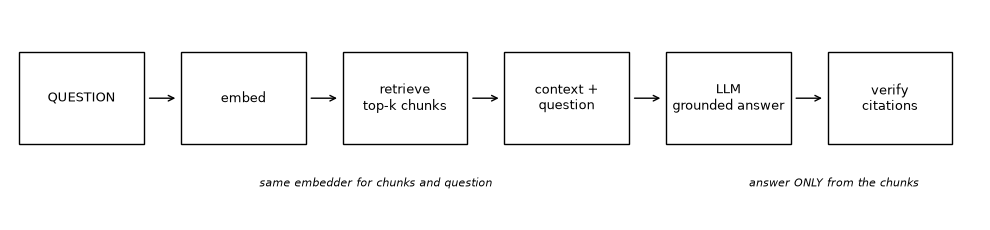

In [2]:
show_rag_pipeline_diagram()

## Steps

1. Run the load + chunk cell. ✓ You see *"N documents → M chunks."*
2. Run the embed cell. ✓ *"embedded M chunks."*
3. Retrieve the top 3 chunks for your question and inspect them.
   ✓ The retrieved chunks are about the question.
4. Edit the grounding instruction so the model answers only from the
   context and cites the source file. ✓ The grounded answer carries
   `[filename]` citations.
5. Run the ungrounded comparison. ✓ You can see the difference.

Run the Setup cell above first.

### Step 1 — Load the four documents and chunk them (5 min)

Chunk = one paragraph (blank-line separated), dropping tiny fragments. The
cell prints the chunk count **and** the sizes — chunk size is the knob you
turn in the stretch section.

In [3]:
chunks = load_policy_chunks()

4 documents → 26 chunks
chunk sizes (chars): min 111, median 249, max 404
  ai_acceptable_use_policy.md: 6 chunks
  data_governance_standard.md: 7 chunks
  foia_processing_guidance.md: 7 chunks
  records_retention_policy.md: 6 chunks


### Step 2 — Embed the chunks (4 min)

One vector per chunk. With a key this uses OpenAI embeddings; offline it falls
back to a deterministic local hasher (dim 256) — good enough to rank four
small documents, which is why the lab works with no network.

In [4]:
vecs = embed_policy_chunks(chunks)

embedded 26 chunks, dim=256
embedder: local hashing fallback (offline)


### Step 3 — Retrieve the top 3 chunks and inspect them (8 min)

The cell embeds your question with the **same** embedder, ranks the chunks by
similarity, and prints the top 3. Read the chunks *before* generating — is
the answer actually in them? Edit the question and re-run.

In [5]:
QUESTION = "How long are program case files kept before they are destroyed?"   # ← YOUR TURN: ask a different question, then re-run this cell

retrieved = show_retrieved_passages(chunks, vecs, QUESTION)

[0.500] records_retention_policy.md
This policy establishes how long agency records are kept and when they are destroyed or transferred
to the National Archives. It implements the agency's records schedule approved by NARA. 

[0.466] records_retention_policy.md
- **Routine administrative correspondence** is retained for 3 years, then destroyed. - **Program
case files** are retained for 7 years after the case is closed. - **Financial and procurement
records** are retained [...] 

[0.429] records_retention_policy.md
Records that have met their retention period are destroyed using methods appropriate to their
sensitivity. Records containing personally identifiable information are shredded or securely wiped.
A destruction log [...] 



### Step 4 — Generate grounded, with citations and quotes (10 min)

The grounding instruction does the work. Yours must make the model:

- answer **only** from the provided context,
- cite the source file in `[brackets]` after every fact,
- quote the exact sentence it relied on,
- and say so plainly when the context does not contain the answer.

That last clause is the one people leave out, and it is the one that stops the
pipeline inventing an answer. A working instruction is provided — edit it and
re-run.

In [6]:
GROUNDING_SYSTEM = """Answer ONLY from the provided context. After every fact, cite the source file in [brackets] and quote the exact sentence you relied on. If the context does not contain the answer, say so — do not use outside knowledge."""   # ← YOUR TURN: edit the grounding instruction, then re-run this cell

answer = ask_gov_docs(QUESTION, retrieved, GROUNDING_SYSTEM)

(offline) canned grounded reply:

Program case files are kept for 7 years after the case is closed, then destroyed [records_retention_policy.md]. The policy states: "Program case files are retained for 7 years after the case is closed." Note the contrast with routine administrative correspondence (3 years) in the same file.


### Step 5 — Run the ungrounded comparison (8 min)

Same question, no context, no retrieval. The cell puts the two answers side
by side — read them as a constituent would: one cites a file you can open,
the other sounds equally confident and is wrong about the period.

In [7]:
compare_with_ungrounded(QUESTION, answer)

GROUNDED (retrieval + citations):

Program case files are kept for 7 years after the case is closed, then
destroyed [records_retention_policy.md]. The policy states: "Program case
files are retained for 7 years after the case is closed." Note the contrast
with routine administrative correspondence (3 years) in the same file.

UNGROUNDED (no retrieval, answered from memory):

Program case files are generally kept for 3 years after the case is closed,
after which they are destroyed. Some agencies keep them longer if litigation
is expected. (Typical ungrounded answer: confident, plausible — and, for this
corpus, wrong about the period.)

✓ Which one would you put in front of a constituent, and why?


## Stretch (not timed)

The workbook page ends at Step 5. Everything below is optional.

### Stretch A — Check every citation against the source file

A citation is a claim, not a fact. The checker below verifies (a) every
`[file.md]` tag names a real corpus file and (b) every quoted sentence
actually appears in the corpus. Run it on your grounded answer.

In [8]:
check_answer_citations(answer)

source [records_retention_policy.md]: exists
quote "Program case files are retained for 7 years after the case i...": verified in records_retention_policy.md


### Stretch B — Confirm or refute one DO NOW 7.D prediction

Take one failure you predicted in DO NOW 7.D and test it. The question below
is designed to fail cleanly: the answer is **absent from all four documents**.
A well-grounded pipeline should say so instead of improvising.

In [9]:
HARD_QUESTION = "What is the agency's AI training budget for fiscal year 2027?"   # ← YOUR TURN: try your own unanswerable question, then re-run this cell

try_unanswerable_question(chunks, vecs, GROUNDING_SYSTEM, HARD_QUESTION)

top chunks for an unanswerable question (note the low scores):
  [0.445] ai_acceptable_use_policy.md: - **Public data** (for example, published reports and open data from [...]
  [0.444] records_retention_policy.md: Electronic records are subject to the same retention periods as their [...]
  [0.442] data_governance_standard.md: Programs collect only the data needed for their mission and retain it only [...]

(offline) canned grounded reply:

The provided documents do not say anything about an AI training budget for fiscal year 2027. No citation is possible.

My 7.D prediction confirmed/refuted (write here): ...


### Stretch C — Change the chunk size and re-run the failing question

Paragraph chunks are one choice. Fixed-width windows are another. The cell
re-chunks at ~450 characters, re-embeds, and re-runs your Step 3 question —
did retrieval change? When would fixed windows beat paragraphs?

In [10]:
CHUNK_WIDTH = 450   # ← YOUR TURN: try a different window width (e.g. 200 or 800), then re-run this cell

try_fixed_width_chunks(QUESTION, width=CHUNK_WIDTH)

fixed-width: 17 chunks (was 26 paragraphs)
[0.476] records_retention_policy.md: retained for 3 years, then destroyed. - **Program case files** are retained for 7 [...]
[0.428] records_retention_policy.md: # Records Retention Policy (Training Excerpt) *Simplified, synthetic training [...]
[0.422] ai_acceptable_use_policy.md: data** (PII, health, financial, law enforcement) may be used only with tools [...]


## Deliverable

1. The top-3 retrieved chunks for the retention question, with scores.
2. The grounded answer whose citations **passed** the Stretch A checker.
3. One line: your DO NOW 7.D prediction, confirmed or refuted, and what fixed
   (or would fix) the failure — chunking or prompting.

## Reflection

1. Did chunking or prompting fix your failing question?
2. How would you detect a wrong citation at scale?
3. What would you tell a programme office promised "95% accuracy"?

## Debrief (instructor-led)

1. Which answer would you put in front of a constituent, and why?
2. What breaks if chunks are too big? Too small?
3. When does RAG *fail* — and which failure is invisible to the user?
4. What does a FedRAMP production version of this pipeline look like?

## Troubleshooting

- **Every question retrieves the same chunks** — offline, the local hashing
  embeddings are character-based and scores cluster; that is expected. With a
  key, real embeddings sharpen the ranking.
- **A red error naming `chunks` or `vecs`** — you ran a later cell before
  Step 1 or 2. Run the notebook in order (Kernel → Restart & Run All).
- **The answer cites the right file but a wrong quote** — that is exactly what
  Stretch A catches. Require an exact quote per claim in `GROUNDING_SYSTEM`.
- **Quote check says NOT FOUND for a real quote** — markdown emphasis (`**`)
  breaks exact matching; the checker's normalizer handles it — make sure you
  re-ran Stretch A after editing the answer.
- **Grounded answer uses outside knowledge anyway** — strengthen the
  instruction ("if the context does not contain the answer, say so") and show
  the model what abstaining looks like (Stretch B).
- **`dim=256` printed in Step 2** — you are on the local fallback (no key);
  retrieval still works, scores just look different.

---
*Curious about the Python behind these steps? The full code-forward version
of this lab lives in the `For_Python_Programmers/` folder.*